In [1]:

# DATA LOADING AND RANDOM TRAINING/VALIDATION/TEST PARTITIONING
import numpy as np
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
import pandas as pd
import os

# Evaluation matrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from lifelines.utils import concordance_index


RANDOM_STATE = 42
BATCH_SIZE = 16

SPLIT_FILE = "data/processed_features/fixed_split_indices.npz"

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: mps


In [ ]:

# CONFIGURATION
FEATURE_DIR = "data/processed/features"

SPLIT_FILE = os.path.join(
    FEATURE_DIR,
    "fixed_split_indices.npz",
)

RANDOM_STATE = 42



# LOAD FEATURES
ligand_features = np.load(
    os.path.join(FEATURE_DIR, "ligand_features.npy"),
    mmap_mode="r",
)

protein_esm_features = np.load(
    os.path.join(FEATURE_DIR, "protein_esm_features.npy"),
    mmap_mode="r",
)

protein_token_features = np.load(
    os.path.join(FEATURE_DIR, "protein_token_features.npy"),
    mmap_mode="r",
)

ligand_index = np.load(
    os.path.join(FEATURE_DIR, "ligand_index.npy")
)

protein_index = np.load(
    os.path.join(FEATURE_DIR, "protein_index.npy")
)

y = np.load(
    os.path.join(FEATURE_DIR, "y.npy")
)



# CREATE / LOAD FIXED SPLIT
if os.path.exists(SPLIT_FILE):

    print("Loading existing split...")

    split = np.load(SPLIT_FILE)

    train_idx = split["train_idx"]
    val_idx = split["val_idx"]
    test_idx = split["test_idx"]

else:

    print("Creating fixed split...")

    indices = np.arange(len(y))

    train_val_idx, test_idx = train_test_split(
        indices,
        test_size=0.20,
        random_state=RANDOM_STATE,
        shuffle=True,
    )

    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=0.20,
        random_state=RANDOM_STATE,
        shuffle=True,
    )

    np.savez(
        SPLIT_FILE,
        train_idx=train_idx,
        val_idx=val_idx,
        test_idx=test_idx,
    )



# MACHINE LEARNING DATA
def get_ml_data():

    X_train = np.concatenate(
        [
            ligand_features[ligand_index[train_idx]],
            protein_esm_features[protein_index[train_idx]],
        ],
        axis=1,
    )

    X_val = np.concatenate(
        [
            ligand_features[ligand_index[val_idx]],
            protein_esm_features[protein_index[val_idx]],
        ],
        axis=1,
    )

    X_test = np.concatenate(
        [
            ligand_features[ligand_index[test_idx]],
            protein_esm_features[protein_index[test_idx]],
        ],
        axis=1,
    )

    y_train = y[train_idx]
    y_val = y[val_idx]
    y_test = y[test_idx]

    return (
        X_train,
        X_val,
        X_test,

        y_train,
        y_val,
        y_test,
    )



# DEEP LEARNING DATA
def get_deep_learning_data():

    X_lig_train = ligand_features[
        ligand_index[train_idx]
    ]

    X_lig_val = ligand_features[
        ligand_index[val_idx]
    ]

    X_lig_test = ligand_features[
        ligand_index[test_idx]
    ]


    X_prot_train = protein_token_features[
        protein_index[train_idx]
    ]

    X_prot_val = protein_token_features[
        protein_index[val_idx]
    ]

    X_prot_test = protein_token_features[
        protein_index[test_idx]
    ]


    y_train = y[train_idx]
    y_val = y[val_idx]
    y_test = y[test_idx]


    return (
        X_lig_train,
        X_prot_train,
        y_train,

        X_lig_val,
        X_prot_val,
        y_val,

        X_lig_test,
        X_prot_test,
        y_test,
    )

Loading existing split...


In [ ]:
(X_lig_train,
X_prot_train,
y_train,

X_lig_val,
X_prot_val,
y_val,

X_lig_test,
X_prot_test,
y_test) = get_deep_learning_data()

In [ ]:


# 4. VERIFY FIXED SPLITS
print("\nFinal dataset partition:")
print("Training samples  :", len(train_idx))
print("Validation samples:", len(val_idx))
print("Test samples      :", len(test_idx))


Final dataset partition:
Training samples  : 298715
Validation samples: 74679
Test samples      : 93349


In [ ]:


# CUSTOM PYTORCH DATASET FOR DRUG–TARGET INTERACTION DATA
class DrugTargetDataset(Dataset):
    """
    Custom PyTorch Dataset for drug–target affinity regression.

    Each observation consists of:
        1. A numerical ligand representation.
        2. A numerical protein representation.
        3. A continuous binding-affinity target (pKi).

    The Dataset class provides indexed access to individual
    drug–target pairs and converts the stored NumPy arrays into
    PyTorch tensors suitable for model training and evaluation.
    """

    def __init__(self, lig, prot, y):
        """
        Initialise the dataset.

        Parameters
        --
        lig : array-like
            Numerical ligand representations corresponding to
            individual drug molecules.

        prot : array-like
            Numerical protein representations corresponding to
            the associated protein targets.

        y : array-like
            Continuous target values representing experimentally
            derived drug–target binding affinity expressed as pKi.
        """

        # Store the ligand representations. Each row corresponds
        # to one drug molecule in a drug–target interaction pair.
        self.lig = lig

        # Store the corresponding protein representations.
        # The ith protein representation must correspond to the
        # same interaction record as the ith ligand representation.
        self.prot = prot

        # Store the continuous affinity values used as the
        # regression targets during supervised model training.
        self.y = y


    def __len__(self):
        """
        Return the total number of drug–target interaction records.

        The number of target values is used because each affinity
        measurement corresponds to exactly one ligand–protein pair.
        """
        return len(self.y)


    def __getitem__(self, idx):
        """
        Retrieve and convert a single drug–target interaction sample.

        Parameters
        --
        idx : int
            Index of the requested observation.

        Returns
        ---
        ligand : torch.Tensor
            Ligand representation converted to 32-bit floating point.

        protein : torch.Tensor
            Protein representation converted to an integer tensor.

        target : torch.Tensor
            Experimental pKi value represented as a 32-bit
            floating-point tensor.
        """

        return (
            # Molecular features are represented as floating-point
            # values before being provided to the ligand encoder.
            torch.tensor(
                self.lig[idx],
                dtype=torch.float32
            ),

            # Protein representations are converted to integer
            # tensors because this implementation assumes that the
            # protein input contains tokenised amino-acid indices
            # that are subsequently processed by an embedding layer.
            torch.tensor(
                self.prot[idx],
                dtype=torch.long
            ),

            # The pKi response variable is represented as a
            # floating-point value because affinity prediction is
            # formulated as a continuous regression problem.
            torch.tensor(
                self.y[idx],
                dtype=torch.float32
            ),
        )

In [ ]:

# DATASET INSTANTIATION
# Construct PyTorch Dataset objects for the training, validation,
# and test partitions. Each dataset maintains the correspondence
# between the ligand representation, protein representation, and
# associated scaled pKi target value.



# DATASET INSTANTIATION
# Construct PyTorch Dataset objects for the training, validation,
# and test partitions. Each dataset maintains the correspondence
# between the ligand representation, protein representation, and
# associated scaled pKi target value.

train_dataset = DrugTargetDataset(
    X_lig_train,
    X_prot_train,
    y_train
)

val_dataset = DrugTargetDataset(
    X_lig_val,
    X_prot_val,
    y_val
)

test_dataset = DrugTargetDataset(
    X_lig_test,
    X_prot_test,
    y_test
)

BATCH_SIZE = 32



# DATA LOADER CONFIGURATION
# Create the DataLoader used during model training.
#
# Samples are processed in mini-batches of size BATCH_SIZE.
# Shuffling is enabled for the training dataset so that the
# ordering of observations changes between epochs. This reduces
# the likelihood that the optimisation process becomes dependent
# on the original ordering of the training observations and
# supports more stable stochastic gradient-based optimisation.

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)


# Construct the validation DataLoader.
#
# Shuffling is disabled because the validation partition is not
# used to update model parameters. Maintaining a deterministic
# ordering also facilitates reproducible model evaluation and
# comparison across training epochs.

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# Construct the test DataLoader.
#
# The test dataset is evaluated only after model development and
# hyperparameter selection. Therefore, shuffling is unnecessary,
# and the original observation order is retained to support
# reproducible final performance assessment.

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:

# EXPERIMENTAL AND MODEL CONFIGURATION
# Define the dimensionality of the ligand representation.
# Each drug molecule is represented using a 1,024-dimensional
# Morgan fingerprint. The fixed dimensionality provides a
# consistent numerical representation for input to the ligand
# encoder.
FP_SIZE = 1024


# Define the maximum protein sequence length considered by the
# model. Protein sequences longer than 300 amino-acid residues
# are truncated during preprocessing, while shorter sequences
# are padded where required to obtain a fixed-length input.
#
# This constraint reduces computational and memory requirements
# and ensures that protein sequences can be processed in
# uniformly shaped mini-batches.
MAX_LEN = 300


# Specify the number of drug–target interaction samples processed
# simultaneously during each optimisation step.
#
# A mini-batch size of 16 provides a compromise between memory
# consumption, computational efficiency, and the stochastic
# behaviour of gradient-based optimisation.
BATCH_SIZE = 23


# Define the maximum number of complete passes through the
# training dataset.
#
# Training is permitted to continue for up to 100 epochs.
# When early stopping is implemented, this value represents an
# upper training limit rather than requiring the model to
# complete all 10 epochs.
EPOCHS = 100

In [ ]:
import torch
import torch.nn as nn



# MULTIMODAL DRUG–TARGET AFFINITY REGRESSION MODEL
class DTIRegressor(nn.Module):
    """
    Neural network for drug–target affinity prediction.

    The model processes two heterogeneous biological modalities:

    1. Ligand representation:
       A fixed-length Morgan fingerprint describing the
       structural characteristics of the drug molecule.

       Expected shape:
           [batch_size, fingerprint_size]

    2. Protein representation:
       A fixed-length sequence of integer-encoded amino-acid
       tokens.

       Expected shape:
           [batch_size, sequence_length]

    The ligand and protein representations are independently
    encoded into latent feature vectors before being concatenated
    and processed by a fully connected regression head.

    Output:
        Continuous predicted binding affinity expressed as pKi.

        Shape:
            [batch_size]
    """

    def __init__(
        self,
        fingerprint_size=1024,
        protein_vocab_size=22,
        protein_embedding_dim=128,
        padding_idx=0,
        dropout_rate=0.3,
    ):
        """
        Initialise the drug–target affinity regression model.

        Parameters
        --
        fingerprint_size : int
            Dimensionality of the Morgan fingerprint used to
            represent each ligand.

        protein_vocab_size : int
            Number of unique amino-acid/token indices available
            in the protein vocabulary, including the padding token.

        protein_embedding_dim : int
            Dimensionality of the trainable amino-acid embedding
            representation.

        padding_idx : int
            Index reserved for sequence padding. The corresponding
            embedding vector is fixed at zero.

        dropout_rate : float
            Dropout probability used for regularisation within
            the ligand, protein, and regression components.
        """

        super().__init__()

        # Store important architectural parameters for subsequent
        # validation of the input tensors.
        self.fingerprint_size = fingerprint_size
        self.padding_idx = padding_idx


        
        # LIGAND ENCODER
        

        # Morgan fingerprints are fixed-length binary vectors in
        # which individual positions correspond to hashed molecular
        # substructures. Unlike sequential data, neighbouring
        # fingerprint positions do not possess an intrinsic spatial
        # or sequential relationship.
        #
        # Consequently, a multilayer perceptron (MLP) is used rather
        # than a convolutional architecture.
        #
        # Dimensionality:
        #
        # 1024 -> 512 -> 256 -> 128

        self.ligand_encoder = nn.Sequential(

            # First nonlinear projection from the original
            # fingerprint space to a lower-dimensional latent space.
            nn.Linear(fingerprint_size, 512),

            # Batch normalisation stabilises the distribution of
            # intermediate activations and can facilitate optimisation.
            nn.BatchNorm1d(512),

            # ReLU introduces non-linearity, allowing the model to
            # represent complex structure–affinity relationships.
            nn.ReLU(),

            # Dropout provides regularisation by randomly deactivating
            # a proportion of hidden units during training.
            nn.Dropout(dropout_rate),

            # Further dimensionality reduction.
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Final ligand representation.
            nn.Linear(256, 128),
            nn.ReLU(),
        )


        
        # PROTEIN TOKEN EMBEDDING
        
        # Integer-encoded amino-acid tokens cannot be processed
        # meaningfully as continuous numerical quantities because
        # their integer values represent categorical identities
        # rather than magnitudes.
        #
        # A trainable embedding layer therefore maps each amino-acid
        # token to a dense 128-dimensional continuous vector.

        self.protein_embedding = nn.Embedding(
            num_embeddings=protein_vocab_size,
            embedding_dim=protein_embedding_dim,
            padding_idx=padding_idx,
        )


        
        # PROTEIN SEQUENCE ENCODER
        
        # A one-dimensional convolutional neural network is used
        # to learn local sequence patterns from the embedded amino-
        # acid representation.
        #
        # This architecture is suitable because neighbouring amino
        # acids possess biologically meaningful sequential context,
        # and convolutional filters can detect recurring local
        # sequence motifs.
        #
        # A kernel size of five allows each convolutional operation
        # to examine local windows spanning five residue positions.

        self.protein_encoder = nn.Sequential(

            # First convolutional layer.
            nn.Conv1d(
                in_channels=protein_embedding_dim,
                out_channels=128,
                kernel_size=5,
                padding=2,
            ),

            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Second convolutional layer provides additional
            # nonlinear transformation of local sequence features.
            nn.Conv1d(
                in_channels=128,
                out_channels=128,
                kernel_size=5,
                padding=2,
            ),

            nn.BatchNorm1d(128),
            nn.ReLU(),
        )


        
        # MULTIMODAL FUSION AND REGRESSION HEAD
        
        # Both modality-specific encoders produce 128-dimensional
        # vectors:
        #
        #     Ligand representation  = 128
        #     Protein representation = 128
        #
        # Concatenation therefore generates a joint
        # 256-dimensional drug–target representation.
        #
        # The fused representation is subsequently transformed
        # through fully connected layers to estimate binding
        # affinity as a single continuous pKi value.

        self.regression_head = nn.Sequential(

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            # A slightly larger dropout probability is applied
            # immediately after feature fusion to reduce potential
            # overfitting within the joint representation.
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Final regression output containing one scalar affinity
            # prediction for each drug–target pair.
            nn.Linear(128, 1),
        )


        # Apply explicit parameter initialisation after all model
        # components have been constructed.
        self._initialize_weights()


    
    # PARAMETER INITIALISATION
    
    def _initialize_weights(self):
        """
        Initialise trainable model parameters.

        Kaiming normal initialisation is applied to linear and
        convolutional layers because these layers are followed
        predominantly by ReLU activation functions.

        Protein embedding weights are initialised from a small
        normal distribution. The embedding corresponding to the
        padding token is explicitly maintained as a zero vector.
        """

        for module in self.modules():

            
            # Fully connected layers
            if isinstance(module, nn.Linear):

                nn.init.kaiming_normal_(
                    module.weight,
                    nonlinearity="relu",
                )

                if module.bias is not None:
                    nn.init.zeros_(module.bias)


            
            # One-dimensional convolutional layers
            elif isinstance(module, nn.Conv1d):

                nn.init.kaiming_normal_(
                    module.weight,
                    nonlinearity="relu",
                )

                if module.bias is not None:
                    nn.init.zeros_(module.bias)


            
            # Amino-acid embedding layer
            elif isinstance(module, nn.Embedding):

                nn.init.normal_(
                    module.weight,
                    mean=0.0,
                    std=0.02,
                )

                # Ensure that the padding token does not contribute
                # a learned representation.
                if module.padding_idx is not None:

                    with torch.no_grad():
                        module.weight[
                            module.padding_idx
                        ].zero_()


    
    # MASKED GLOBAL MAX POOLING
    def masked_max_pool(
        self,
        protein_features,
        protein_mask,
    ):
        """
        Perform global max pooling across the protein sequence
        while excluding padded positions.

        Parameters
        --
        protein_features : torch.Tensor
            Protein feature tensor with dimensions:

            [batch_size, channels, sequence_length]

        protein_mask : torch.Tensor
            Boolean mask with dimensions:

            [batch_size, sequence_length]

            True values identify genuine amino-acid positions,
            whereas False values identify padding.

        Returns
        ---
        torch.Tensor
            Fixed-length protein representation with dimensions:

            [batch_size, channels]
        """

        # Extend the mask with a channel dimension so that it can
        # be broadcast across all convolutional feature channels.
        #
        # [batch, sequence_length]
        #            ->
        # [batch, 1, sequence_length]

        protein_mask = protein_mask.unsqueeze(1)


        # Assign a very small floating-point value to padded
        # positions before max pooling. This prevents artificial
        # padding values from being selected as sequence maxima.
        protein_features = protein_features.masked_fill(
            ~protein_mask,
            torch.finfo(protein_features.dtype).min,
        )


        # Perform global maximum pooling over the sequence
        # dimension.
        #
        # [batch, 128, sequence_length]
        #            ->
        # [batch, 128]

        pooled_features = protein_features.max(dim=2).values


        # Identify pathological cases in which a protein sequence
        # contains no valid amino-acid tokens and consists entirely
        # of padding.
        invalid_sequences = ~protein_mask.any(dim=2)


        # Replace representations of completely padded sequences
        # with zero vectors to prevent extreme negative values from
        # propagating through the network.
        if invalid_sequences.any():

            pooled_features = pooled_features.masked_fill(
                invalid_sequences,
                0.0,
            )


        return pooled_features


    
    # FORWARD PROPAGATION
    def forward(self, ligand, protein):
        """
        Perform forward propagation through the multimodal model.

        Parameters
        --
        ligand : torch.Tensor
            Morgan fingerprint tensor with dimensions:

            [batch_size, fingerprint_size]

        protein : torch.Tensor
            Integer-encoded protein sequence tensor with dimensions:

            [batch_size, sequence_length]

        Returns
        ---
        torch.Tensor
            Predicted pKi values with dimensions:

            [batch_size]
        """


        
        # INPUT VALIDATION
        
        # Verify that ligand inputs follow the required
        # two-dimensional batch representation.
        if ligand.ndim != 2:

            raise ValueError(
                "Ligand input must have shape "
                "[batch_size, fingerprint_size]."
            )


        # Verify consistency between the observed fingerprint
        # dimensionality and the model configuration.
        if ligand.size(1) != self.fingerprint_size:

            raise ValueError(
                f"Expected {self.fingerprint_size} ligand features, "
                f"but received {ligand.size(1)}."
            )


        # Protein input must contain one token sequence per sample.
        if protein.ndim != 2:

            raise ValueError(
                "Protein input must have shape "
                "[batch_size, sequence_length]."
            )


        # Ensure that each ligand corresponds to exactly one
        # protein sequence within the same mini-batch.
        if ligand.size(0) != protein.size(0):

            raise ValueError(
                "Ligand and protein inputs must have the same batch size."
            )


        
        # DATA TYPE STANDARDISATION
        
        # Morgan fingerprints are represented as floating-point
        # tensors for processing by fully connected neural layers.
        ligand = ligand.float()

        # Protein token indices must use integer type because they
        # are passed to the nn.Embedding lookup layer.
        protein = protein.long()


        
        # LIGAND FEATURE EXTRACTION
        
        # Convert the original 1,024-dimensional Morgan fingerprint
        # into a learned 128-dimensional ligand representation.
        #
        # [batch, 1024] -> [batch, 128]

        ligand_features = self.ligand_encoder(ligand)


        
        # PROTEIN FEATURE EXTRACTION
        
        # Generate a Boolean mask distinguishing valid amino-acid
        # positions from padded positions.
        protein_mask = protein.ne(self.padding_idx)


        # Convert integer amino-acid tokens into continuous,
        # trainable embedding vectors.
        #
        # [batch, sequence_length]
        #            ->
        # [batch, sequence_length, embedding_dim]

        protein_features = self.protein_embedding(protein)


        # PyTorch Conv1d expects the channel dimension before the
        # sequence dimension. The embedding tensor is therefore
        # rearranged accordingly.
        #
        # [batch, sequence_length, embedding_dim]
        #                    ->
        # [batch, embedding_dim, sequence_length]

        protein_features = protein_features.permute(
            0,
            2,
            1,
        )


        # Apply the convolutional sequence encoder to learn
        # local amino-acid patterns and motifs.
        #
        # Output:
        # [batch, 128, sequence_length]

        protein_features = self.protein_encoder(
            protein_features
        )


        # Aggregate variable-length sequence information into a
        # fixed 128-dimensional protein representation while
        # excluding padded positions.
        #
        # [batch, 128, sequence_length]
        #            ->
        # [batch, 128]

        protein_features = self.masked_max_pool(
            protein_features,
            protein_mask,
        )


        
        # MULTIMODAL FEATURE FUSION
        
        # Concatenate the learned ligand and protein representations
        # along the feature dimension.
        #
        # Ligand:  [batch, 128]
        # Protein: [batch, 128]
        #
        # Combined:
        #          [batch, 256]

        combined_features = torch.cat(
            [
                ligand_features,
                protein_features,
            ],
            dim=1,
        )


        
        # AFFINITY REGRESSION
        
        # Process the fused drug–target representation through
        # the regression head to generate a single continuous
        # affinity prediction for each interaction.
        #
        # [batch, 256] -> [batch, 1]

        predictions = self.regression_head(
            combined_features
        )


        # Remove the final singleton dimension:
        #
        # [batch, 1] -> [batch]
        #
        # This shape is convenient for comparison with the
        # one-dimensional ground-truth pKi tensor.

        return predictions.squeeze(-1)

In [ ]:

# MODEL INITIALISATION

# Instantiate the proposed drug–target affinity regression model.
#
# The ligand branch receives 1,024-dimensional Morgan fingerprints,
# while the protein branch processes integer-encoded amino-acid
# sequences using a trainable embedding layer followed by a
# one-dimensional convolutional encoder.
#
# The complete model is transferred to the selected computational
# device (Apple MPS when available, otherwise CPU).

model = DTIRegressor(
    fingerprint_size=1024,
    protein_vocab_size=22,
    protein_embedding_dim=128,
    padding_idx=0,
    dropout_rate=0.3,
).to(device)


# Display the instantiated architecture to verify the model
# configuration and individual network components before training.
print(model)



# LOSS FUNCTION

# Mean squared error (MSE) was considered as a conventional
# regression objective:
#
# loss_fn = nn.MSELoss()
#
# However, Huber loss is used as the optimisation objective in
# the final configuration. Huber loss behaves approximately
# quadratically for small prediction errors and linearly for
# larger errors. Consequently, it is less sensitive to extreme
# residuals than conventional MSE while remaining differentiable
# and suitable for gradient-based optimisation.
#
# delta=1.0 defines the transition point between the quadratic
# and linear components of the Huber loss function.

loss_fn = nn.HuberLoss(delta=1.0)



# OPTIMISER

# AdamW is used to optimise the trainable model parameters.
#
# AdamW extends the Adam optimisation algorithm by applying
# decoupled weight decay, allowing regularisation to be controlled
# independently from the adaptive gradient updates.
#
# Learning rate:
#     3 × 10^-4
#
# Weight decay:
#     1 × 10^-4
#
# The weight-decay term provides additional regularisation and
# can reduce overfitting by discouraging excessively large model
# parameters.

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-3,
)



# ADAPTIVE LEARNING-RATE SCHEDULER


# ReduceLROnPlateau dynamically decreases the learning rate when
# validation performance stops improving.
#
# mode="min":
#     Lower validation loss represents improved performance.
#
# factor=0.5:
#     The current learning rate is multiplied by 0.5 whenever
#     the reduction criterion is satisfied.
#
# patience=5:
#     The scheduler waits for five validation evaluations without
#     sufficient improvement before reducing the learning rate.
#
# This strategy allows relatively large optimisation steps during
# the earlier stages of training while enabling finer parameter
# updates once validation performance begins to plateau.

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)



# EARLY-STOPPING CONFIGURATION

# Initialise the best observed validation loss to positive
# infinity. Any finite validation loss obtained during the first
# training epoch will therefore represent an improvement.

best_val_loss = float("inf")

# Define the early-stopping patience.
#
# Training will be terminated if the validation loss fails to
# improve for 15 consecutive epochs. This prevents unnecessary
# optimisation once generalisation performance ceases to improve
# and helps reduce the risk of overfitting.

patience = 15

# Counter used to record the number of consecutive epochs without
# improvement in validation loss. The counter is reset to zero
# whenever a new best validation loss is observed.

counter = 0

DTIRegressor(
  (ligand_encoder): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): ReLU()
  )
  (protein_embedding): Embedding(22, 128, padding_idx=0)
  (protein_encoder): Sequential(
    (0): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0

In [ ]:
# Counter recording consecutive epochs without improvement.
counter = 0

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "learning_rate": [],
}



# MODEL TRAINING


for epoch in range(EPOCHS):

    # TRAINING PHASE

    # Set the network to training mode. This activates training-
    # specific behaviour in layers such as Dropout and
    # BatchNorm1d.
    model.train()

    # Accumulate mini-batch losses to calculate the mean training
    # loss for the current epoch.
    running_loss = 0.0

    for ligand, protein, label in train_loader:

        # Transfer the current mini-batch to the selected device.
        ligand = ligand.to(device)
        protein = protein.to(device)
        label = label.to(device)

        
        # FORWARD PROPAGATION

        # Generate predicted affinity values for the current
        # drug–target interaction mini-batch.
        outputs = model(
            ligand,
            protein
        )

        # Calculate the discrepancy between predicted and observed
        # affinity values using Huber loss.
        loss = loss_fn(
            outputs,
            label
        )


        
        # BACKPROPAGATION
        
        # Clear gradients accumulated during the previous
        # optimisation step.
        optimizer.zero_grad()

        # Compute gradients of the loss with respect to all
        # trainable parameters.
        loss.backward()


        
        # GRADIENT CLIPPING
        
        # Limit the global gradient norm to a maximum value of 5.
        # Gradient clipping can improve numerical stability by
        # preventing excessively large gradient updates during
        # optimisation.
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )


        
        # PARAMETER UPDATE
        
        # Update the model parameters using the AdamW optimiser.
        optimizer.step()

        # Accumulate the loss from the current mini-batch.
        running_loss += loss.item()


    # Calculate the mean training loss across all mini-batches
    # processed during the current epoch.
    running_loss /= len(train_loader)


    
    # VALIDATION PHASE
    
    # Switch the network to evaluation mode. This disables
    # dropout and causes batch-normalisation layers to use their
    # stored running statistics rather than updating them.
    model.eval()

    # Accumulate validation loss across all validation batches.
    val_loss = 0.0


    # Gradient computation is unnecessary during validation
    # because no parameter updates are performed.
    with torch.no_grad():

        for ligand, protein, affinity in val_loader:

            # Transfer validation tensors to the selected device.
            ligand = ligand.to(device)
            protein = protein.to(device)
            affinity = affinity.to(device)


            # Generate affinity predictions for the validation
            # drug–target pairs.
            prediction = model(
                ligand,
                protein
            )


            # Calculate validation loss using the same regression
            # objective employed during model training.
            loss = loss_fn(
                prediction,
                affinity
            )


            # Accumulate batch-level validation loss.
            val_loss += loss.item()


    # Calculate the mean validation loss across the complete
    # validation partition.
    val_loss /= len(val_loader)


    
    # LEARNING-RATE ADAPTATION
    
    # Supply validation loss to ReduceLROnPlateau. If validation
    # performance fails to improve for the configured scheduler
    # patience period, the learning rate is reduced.
    scheduler.step(val_loss)


    # Retrieve the current learning rate for training diagnostics.
    current_lr = optimizer.param_groups[0]["lr"]

    
    # RECORD TRAINING HISTORY
    
    history["epoch"].append(epoch + 1)
    history["train_loss"].append(running_loss)
    history["val_loss"].append(val_loss)
    history["learning_rate"].append(current_lr)


    # SAVE TRAINING HISTORY TO CSV

    # The CSV file is updated after every epoch. Consequently,
    # training information is retained even if training is
    # interrupted before all epochs are completed.
    

    history_df = pd.DataFrame(history)

    history_df.to_csv(
        "dti_training_history.csv",
        index=False
    )


    
    # TRAINING PROGRESS

    # Report epoch-level training and validation losses together
    # with the current optimiser learning rate.
    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {running_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"LR: {current_lr:.6f}"
        
    )


    
    # MODEL CHECKPOINTING AND EARLY STOPPING
    
    # Determine whether the current epoch produced a lower
    # validation loss than any previous epoch.
    if val_loss < best_val_loss:

        # Update the best validation performance obtained so far.
        best_val_loss = val_loss

        # best_epoch is updated to reflect the epoch number corresponding
        # to the lowest validation loss observed during training.
        best_epoch = epoch + 1

        # Reset the early-stopping counter because validation
        # performance has improved.
        counter = 0


        # Save the model parameters corresponding to the best
        # observed validation loss. This ensures that subsequent
        # test evaluation uses the model with the strongest
        # validation performance rather than simply the model
        # obtained during the final training epoch.
        torch.save(
            model.state_dict(),
            "best_dti_model.pt"
        )

        print("✓ Best model saved")


    else:

        # Increment the number of consecutive epochs without
        # validation improvement.
        counter += 1

        print(
            f"Early stopping counter: "
            f"{counter}/{patience}"
        )
        

        # Stop training when validation performance has failed to
        # improve for the predefined number of epochs.
        if counter >= patience:

            print("Early stopping triggered")

            break

Epoch [1/100] Train Loss: 0.8925 Val Loss: 0.6403 LR: 0.000200
✓ Best model saved
Epoch [2/100] Train Loss: 0.6970 Val Loss: 0.5861 LR: 0.000200
✓ Best model saved
Epoch [3/100] Train Loss: 0.6233 Val Loss: 0.4970 LR: 0.000200
✓ Best model saved
Epoch [4/100] Train Loss: 0.5726 Val Loss: 0.4698 LR: 0.000200
✓ Best model saved
Epoch [5/100] Train Loss: 0.5354 Val Loss: 0.4168 LR: 0.000200
✓ Best model saved
Epoch [6/100] Train Loss: 0.5040 Val Loss: 0.4044 LR: 0.000200
✓ Best model saved
Epoch [7/100] Train Loss: 0.4807 Val Loss: 0.3831 LR: 0.000200
✓ Best model saved
Epoch [8/100] Train Loss: 0.4601 Val Loss: 0.3711 LR: 0.000200
✓ Best model saved
Epoch [9/100] Train Loss: 0.4417 Val Loss: 0.3682 LR: 0.000200
✓ Best model saved
Epoch [10/100] Train Loss: 0.4261 Val Loss: 0.3508 LR: 0.000200
✓ Best model saved
Epoch [11/100] Train Loss: 0.4130 Val Loss: 0.3482 LR: 0.000200
✓ Best model saved
Epoch [12/100] Train Loss: 0.4021 Val Loss: 0.3395 LR: 0.000200
✓ Best model saved
Epoch [13/100


Training completed.
Best validation loss: 0.2642
Training history saved to: artifacts/figures/dti_training_history.csv


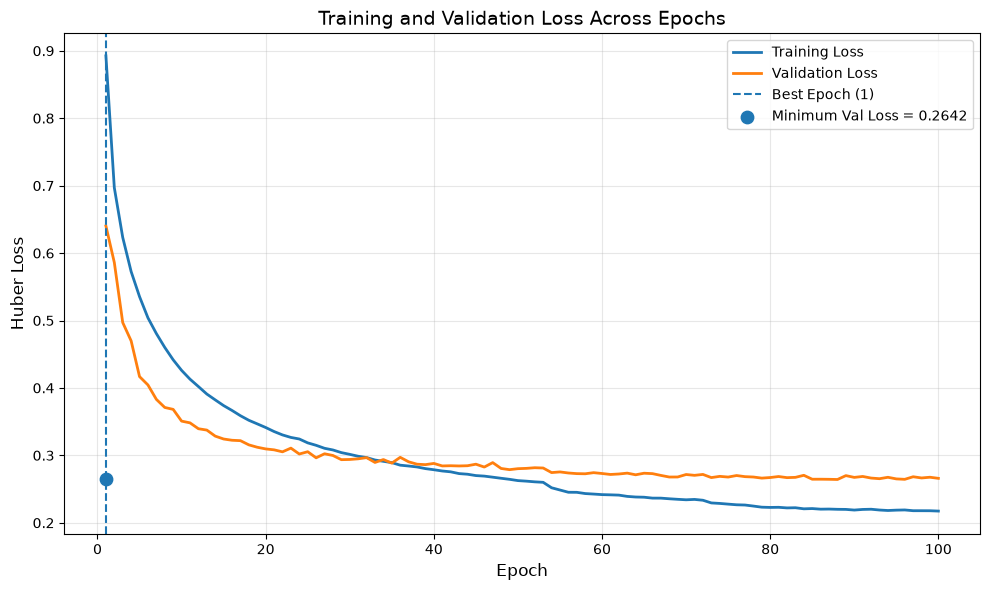

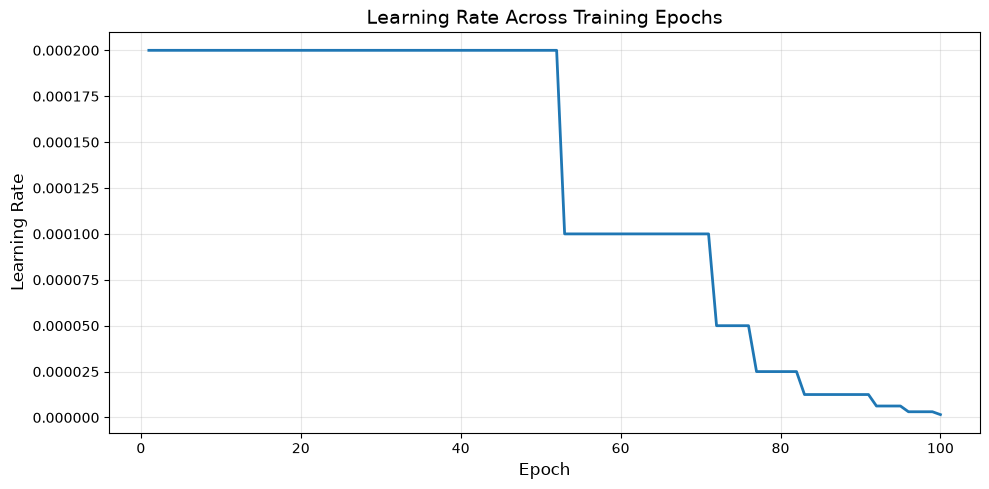

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

best_epoch = 1


# FINAL TRAINING HISTORY

history_df = pd.read_csv("dti_training_history.csv")


print("\nTraining completed.")

print(
    f"Best validation loss: {best_val_loss:.4f}"
)

print(
    "Training history saved to: "
    "artifacts/figures/dti_training_history.csv"
)



# PLOT TRAINING AND VALIDATION LOSS

plt.figure(figsize=(10, 6))


# Plot training loss.
plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss",
    linewidth=2
)


# Plot validation loss.
plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss",
    linewidth=2
)


# Mark the epoch at which the minimum validation loss was
# achieved.
plt.axvline(
    x=best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)


# Mark the actual minimum validation-loss point.
plt.scatter(
    best_epoch,
    best_val_loss,
    s=80,
    zorder=5,
    label=f"Minimum Val Loss = {best_val_loss:.4f}"
)


plt.xlabel(
    "Epoch",
    fontsize=12
)

plt.ylabel(
    "Huber Loss",
    fontsize=12
)

plt.title(
    "Training and Validation Loss Across Epochs",
    fontsize=14
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


# Save publication-quality graph.
plt.savefig(
    "artifacts/figures/dti_training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# PLOT LEARNING-RATE SCHEDULE

plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["learning_rate"],
    linewidth=2
)

plt.xlabel(
    "Epoch",
    fontsize=12
)

plt.ylabel(
    "Learning Rate",
    fontsize=12
)

plt.title(
    "Learning Rate Across Training Epochs",
    fontsize=14
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


plt.savefig(
    "artifacts/figures/dti_learning_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:

# Evaluate predictions


def evaluate_predictions(
    targets,
    predictions
):

    targets = np.asarray(
        targets
    ).ravel()

    predictions = np.asarray(
        predictions
    ).ravel()

    mse = mean_squared_error(
        targets,
        predictions
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        targets,
        predictions
    )

    r2 = r2_score(
        targets,
        predictions
    )

    # Pearson correlation

    if (
        len(targets) > 1
        and np.std(targets) > 0
        and np.std(predictions) > 0
    ):
        pearson = np.corrcoef(
            targets,
            predictions
        )[0, 1]
    else:
        pearson = np.nan

    
    # Concordance Index
    ci = concordance_index(
        targets,
        predictions
    )

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Pearson": pearson,
        "CI": ci
    }

In [ ]:


# Predict an entire split at once

def predict_split(
    model,
    loader,
    device,
    y_scaler=None
):
    """
    Generate predictions and collect targets for one complete
    dataset split.

    If y_scaler is provided, both predictions and targets are
    inverse-transformed back to the original pKi scale.
    """

    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():

        for ligand, protein, y in loader:

            ligand = ligand.to(device)
            protein = protein.to(device)

            # Forward pass
            output = model(
                ligand,
                protein
            )

            # Convert to 1D NumPy arrays
            predictions.append(
                output.detach().cpu().numpy().ravel()
            )

            targets.append(
                y.detach().cpu().numpy().ravel()
            )

    
    # Combine all batches

    predictions = np.concatenate(
        predictions
    )

    targets = np.concatenate(
        targets
    )
    
    return targets, predictions

In [ ]:

# Generate predictions ONCE

y_train_true, y_train_pred = predict_split(
    model,
    train_loader,
    device
)

y_val_true, y_val_pred = predict_split(
    model,
    val_loader,
    device
)

y_test_true, y_test_pred = predict_split(
    model,
    test_loader,
    device
)

In [ ]:

# Evaluate

train_results = evaluate_predictions(
    y_train_true,
    y_train_pred
)

val_results = evaluate_predictions(
    y_val_true,
    y_val_pred
)

test_results = evaluate_predictions(
    y_test_true,
    y_test_pred
)

In [33]:
print(train_results)
print(val_results)
print(test_results)

{'MSE': 0.2981012463569641, 'RMSE': np.float64(0.5459864891707158), 'MAE': 0.3840372860431671, 'R2': 0.8682719469070435, 'Pearson': np.float64(0.9327333799997973), 'CI': np.float64(0.8934026474400383)}
{'MSE': 0.6450777053833008, 'RMSE': np.float64(0.8031672960120455), 'MAE': 0.5785624980926514, 'R2': 0.715538740158081, 'Pearson': np.float64(0.8494897468916194), 'CI': np.float64(0.8318551384466015)}
{'MSE': 0.6508181691169739, 'RMSE': np.float64(0.8067330222055955), 'MAE': 0.5829110145568848, 'R2': 0.7142472267150879, 'Pearson': np.float64(0.8488667628527198), 'CI': np.float64(0.8313684197946075)}


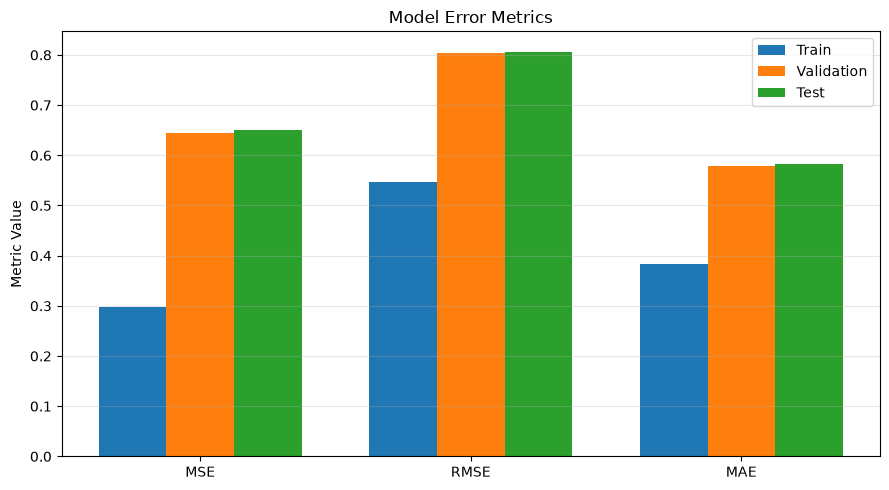

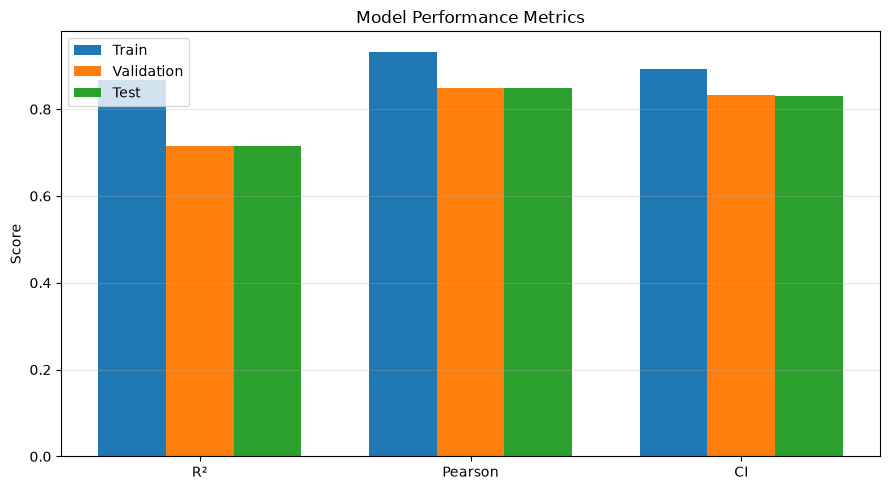

In [ ]:


# 1. ERROR METRICS
error_metrics = ["MSE", "RMSE", "MAE"]

train_error = [train_results[m] for m in error_metrics]
val_error = [val_results[m] for m in error_metrics]
test_error = [test_results[m] for m in error_metrics]


x = np.arange(len(error_metrics))
width = 0.25


plt.figure(figsize=(9, 5))

plt.bar(
    x - width,
    train_error,
    width,
    label="Train"
)

plt.bar(
    x,
    val_error,
    width,
    label="Validation"
)

plt.bar(
    x + width,
    test_error,
    width,
    label="Test"
)

plt.xticks(x, error_metrics)

plt.ylabel("Metric Value")
plt.title("Model Error Metrics")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "artifacts/figures/error_metrics.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()





# 2. PERFORMANCE METRICS

performance_metrics = ["R2", "Pearson", "CI"]

train_performance = [
    train_results[m]
    for m in performance_metrics
]

val_performance = [
    val_results[m]
    for m in performance_metrics
]

test_performance = [
    test_results[m]
    for m in performance_metrics
]


x = np.arange(len(performance_metrics))


plt.figure(figsize=(9, 5))

plt.bar(
    x - width,
    train_performance,
    width,
    label="Train"
)

plt.bar(
    x,
    val_performance,
    width,
    label="Validation"
)

plt.bar(
    x + width,
    test_performance,
    width,
    label="Test"
)

plt.xticks(
    x,
    ["R²", "Pearson", "CI"]
)

plt.ylabel("Score")
plt.title("Model Performance Metrics")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "artifacts/figures/performance_metrics.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

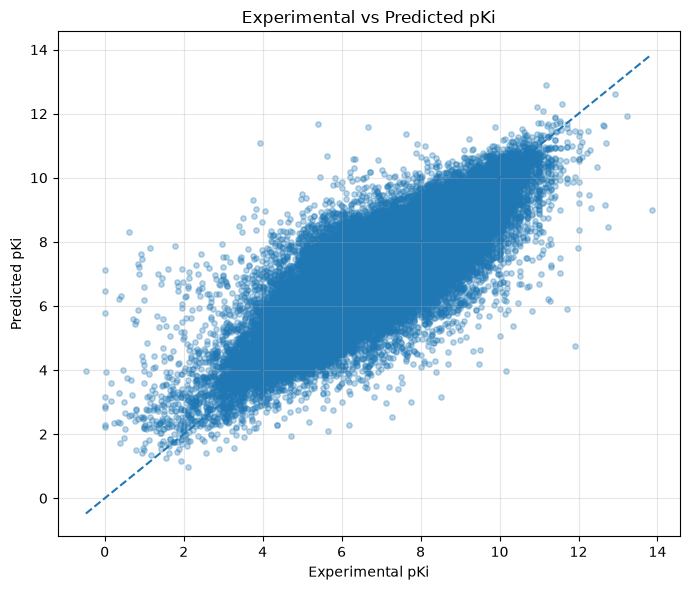

In [31]:

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test_true,
    y_test_pred,
    alpha=0.3,
    s=15
)

minimum = min(
    np.min(y_test_true),
    np.min(y_test_pred)
)

maximum = max(
    np.max(y_test_true),
    np.max(y_test_pred)
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Experimental pKi")
plt.ylabel("Predicted pKi")
plt.title("Experimental vs Predicted pKi")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "artifacts/figures/predicted_vs_actual.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

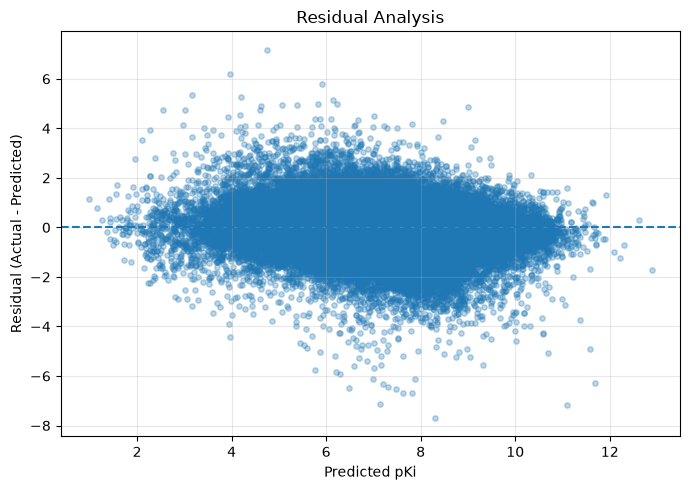

In [32]:
residuals = y_test_true - y_test_pred

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.3,
    s=15
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted pKi")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Analysis")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "artifacts/figures/residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
history_df = pd.read_csv("dti_training_history.csv")

In [43]:
train_losses = history_df['train_loss']
val_losses = history_df['val_loss']

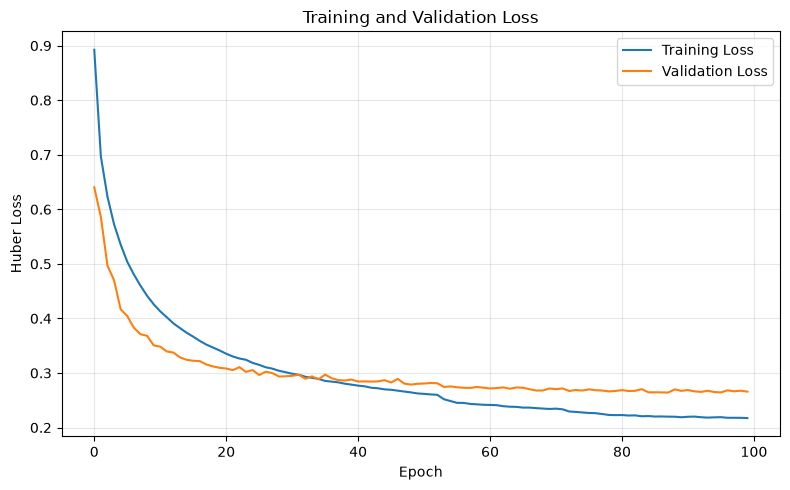

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "artifacts/figures/training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

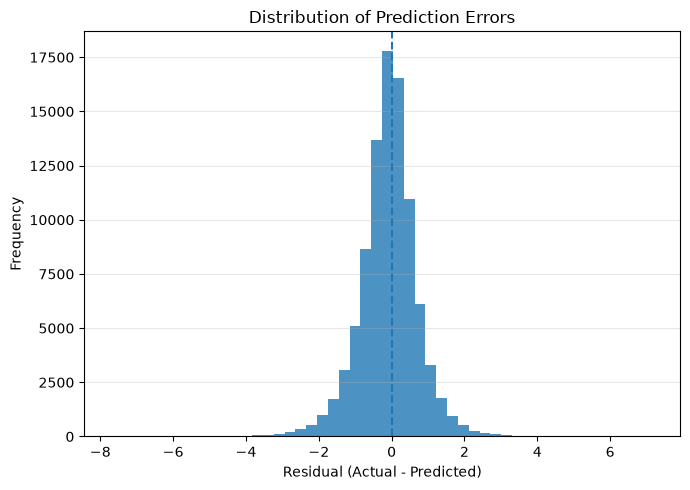

In [34]:
plt.figure(figsize=(7, 5))

plt.hist(
    residuals,
    bins=50,
    alpha=0.8
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "artifacts/figures/residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
def collect_samples(loader, number_of_samples):

    ligand_samples = []
    protein_samples = []

    collected = 0

    for ligand, protein, _ in loader:

        remaining = number_of_samples - collected

        if remaining <= 0:
            break

        batch_size = min(
            remaining,
            ligand.shape[0]
        )

        ligand_samples.append(
            ligand[:batch_size]
            .detach()
            .cpu()
            .numpy()
            .astype(np.float32)
        )

        protein_samples.append(
            protein[:batch_size]
            .detach()
            .cpu()
            .numpy()
            .astype(np.int64)
        )

        collected += batch_size

    ligand_samples = np.concatenate(
        ligand_samples,
        axis=0
    )

    protein_samples = np.concatenate(
        protein_samples,
        axis=0
    )

    return ligand_samples, protein_samples

SHAP SECTION

In [ ]:
import shap

model.eval()

BACKGROUND_SIZE = 10
NUMBER_TO_EXPLAIN = 20
SHAP_EVALUATIONS = 500
PREDICTION_BATCH_SIZE = 256


background_ligand, background_protein = collect_samples(
    train_loader,
    BACKGROUND_SIZE
)

print(
    "Background samples:",
    background_ligand.shape[0]
)

test_ligand, test_protein = collect_samples(
    test_loader,
    NUMBER_TO_EXPLAIN
)

ligand_dimension = background_ligand.shape[1]
protein_length = background_protein.shape[1]

print("Ligand dimension:", ligand_dimension)
print("Protein length:", protein_length)


background_combined = np.concatenate(
    [
        background_ligand,
        background_protein.astype(np.float32)
    ],
    axis=1
)

test_combined = np.concatenate(
    [
        test_ligand,
        test_protein.astype(np.float32)
    ],
    axis=1
)

def predict_combined(combined_input):
    combined_input = np.asarray(
        combined_input,
        dtype=np.float32
    )

    ligand_input = combined_input[
        :,
        :ligand_dimension
    ]

    protein_input = combined_input[
        :,
        ligand_dimension:
        ligand_dimension + protein_length
    ]

    # Masking uses values from the background dataset.
    # Convert protein values back to integer token indices.
    protein_input = np.rint(
        protein_input
    ).astype(np.int64)

    predictions = []

    for start_index in range(
        0,
        combined_input.shape[0],
        PREDICTION_BATCH_SIZE
    ):
        end_index = (
            start_index
            + PREDICTION_BATCH_SIZE
        )

        ligand_batch = torch.tensor(
            ligand_input[start_index:end_index],
            dtype=torch.float32,
            device=device
        )

        protein_batch = torch.tensor(
            protein_input[start_index:end_index],
            dtype=torch.long,
            device=device
        )

        with torch.no_grad():
            batch_prediction = model(
                ligand_batch,
                protein_batch
            )

        predictions.append(
            batch_prediction
            .detach()
            .cpu()
            .numpy()
            .reshape(-1)
        )

    return np.concatenate(
        predictions,
        axis=0
    )

direct_ligand = torch.tensor(
    test_ligand,
    dtype=torch.float32,
    device=device
)

direct_protein = torch.tensor(
    test_protein,
    dtype=torch.long,
    device=device
)

with torch.no_grad():
    direct_prediction = model(
        direct_ligand,
        direct_protein
    ).detach().cpu().numpy().reshape(-1)


wrapper_prediction = predict_combined(
    test_combined
)

print("Direct prediction:", direct_prediction)
print("Wrapper prediction:", wrapper_prediction)

# Feature names

assert np.allclose(
    direct_prediction,
    wrapper_prediction,
    atol=1e-5
), "Combined wrapper prediction does not match the model."


ligand_feature_names = [
    f"Morgan_bit_{index}"
    for index in range(ligand_dimension)
]

protein_feature_names = [
    f"Protein_position_{index + 1}"
    for index in range(protein_length)
]

combined_feature_names = (
    ligand_feature_names
    + protein_feature_names
)


explainer = shap.KernelExplainer(
    model=predict_combined,
    data=background_combined,
    feature_names=combined_feature_names,
    link="identity"
)

shap_values = explainer.shap_values(
    test_combined,
    nsamples=SHAP_EVALUATIONS,
    l1_reg="num_features(30)",
    silent=False
)


if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.asarray(shap_values)

if shap_values.ndim == 3 and shap_values.shape[-1] == 1:
    shap_values = shap_values[:, :, 0]

print("Combined SHAP shape:", shap_values.shape)



if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.asarray(shap_values)

if shap_values.ndim == 3 and shap_values.shape[-1] == 1:
    shap_values = shap_values[:, :, 0]

print("Combined SHAP shape:", shap_values.shape)



# Separate ligand and protein SHAP values
ligand_shap_values = shap_values[
    :,
    :ligand_dimension
]

protein_shap_values = shap_values[
    :,
    ligand_dimension:
    ligand_dimension + protein_length
]

print(
    "Ligand SHAP shape:",
    ligand_shap_values.shape
)

print(
    "Protein SHAP shape:",
    protein_shap_values.shape
)

/Users/bikaschaudharytharu/python/Drug-target-interaction-using-machine-learning/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Background samples: 10
Ligand dimension: 1024
Protein length: 500
Direct prediction: [5.589942  6.0609336 7.9779887 6.88888   6.9446483 6.7396107 6.9520802
 6.6824093 9.235397  6.189926  7.469756  7.262503  8.082193  8.286929
 5.624148  7.607175  7.1282635 7.560583  8.6395    7.4883127]
Wrapper prediction: [5.589942  6.0609336 7.9779887 6.88888   6.9446483 6.7396107 6.9520802
 6.6824093 9.235397  6.189926  7.469756  7.262503  8.082193  8.286929
 5.624148  7.607175  7.1282635 7.560583  8.6395    7.4883127]


100%|██████████| 20/20 [00:15<00:00,  1.31it/s]

Combined SHAP shape: (20, 1524)
Combined SHAP shape: (20, 1524)
Ligand SHAP shape: (20, 1024)
Protein SHAP shape: (20, 500)


In [ ]:
global_mean_abs_shap = np.mean(
    np.abs(shap_values),
    axis=0
)


global_mean_signed_shap = np.mean(
    shap_values,
    axis=0
)

feature_types = (
    ["Ligand"] * ligand_dimension
    +
    ["Protein"] * protein_length
)



# Global importance DataFrame
global_importance_df = pd.DataFrame(
    {
        "Feature": combined_feature_names,
        "Feature_Type": feature_types,
        "Mean_Abs_SHAP": global_mean_abs_shap,
        "Mean_Signed_SHAP": global_mean_signed_shap
    }
)

global_importance_df = (
    global_importance_df
    .sort_values(
        "Mean_Abs_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

global_importance_df.insert(
    0,
    "Rank",
    np.arange(
        1,
        len(global_importance_df) + 1
    )
)



Top 30 global SHAP features
 Rank              Feature Feature_Type  Mean_Abs_SHAP  Mean_Signed_SHAP
    1       Morgan_bit_696       Ligand       0.017141          0.017141
    2 Protein_position_488      Protein       0.014525          0.014525
    3       Morgan_bit_490       Ligand       0.014497          0.014497
    4       Morgan_bit_702       Ligand       0.014159          0.014159
    5       Morgan_bit_733       Ligand       0.012268          0.012268
    6       Morgan_bit_458       Ligand       0.012113         -0.004997
    7 Protein_position_456      Protein       0.011888          0.001140
    8 Protein_position_370      Protein       0.011478         -0.011478
    9       Morgan_bit_207       Ligand       0.011095          0.011095
   10       Morgan_bit_208       Ligand       0.010238          0.010238
   11       Morgan_bit_518       Ligand       0.009852          0.009852
   12        Morgan_bit_99       Ligand       0.009568         -0.009568
   13       Morgan_bit

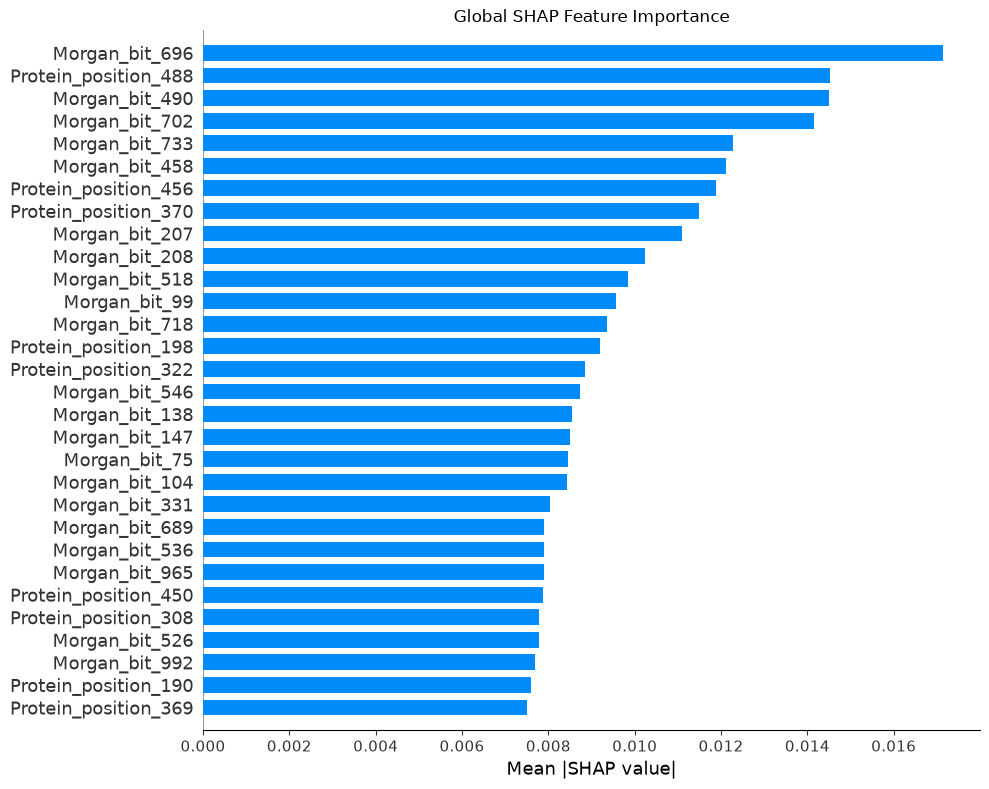

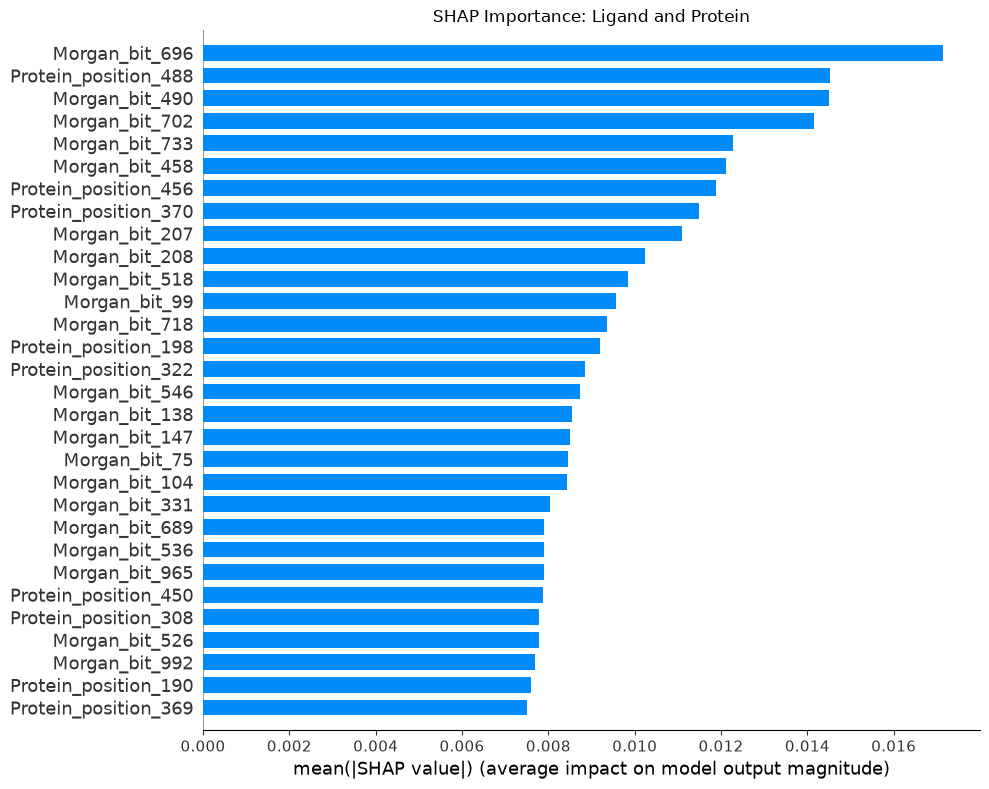

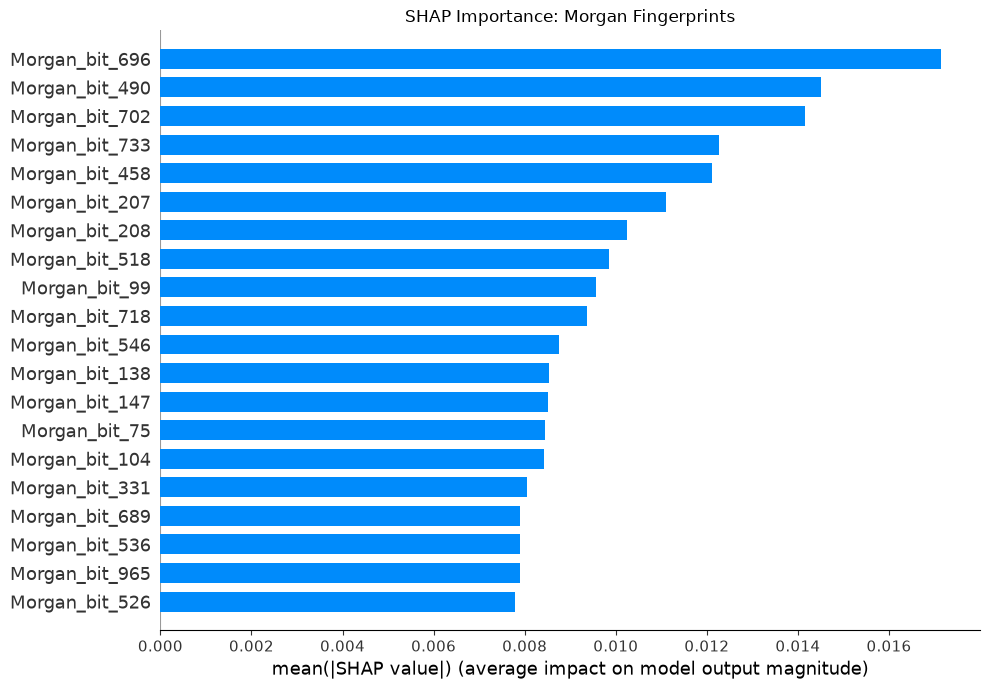

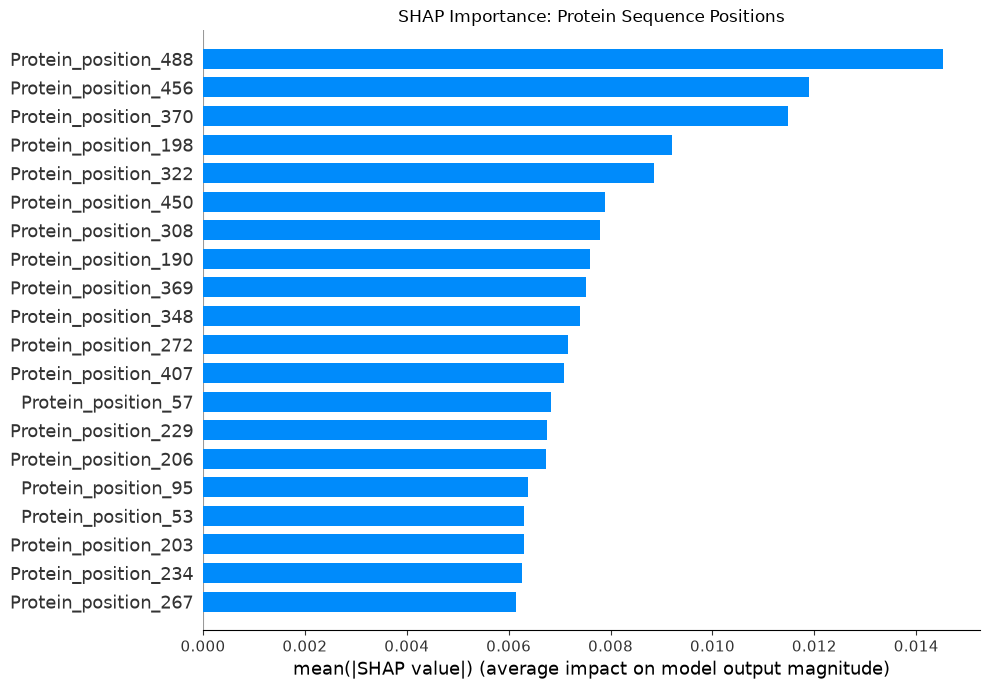

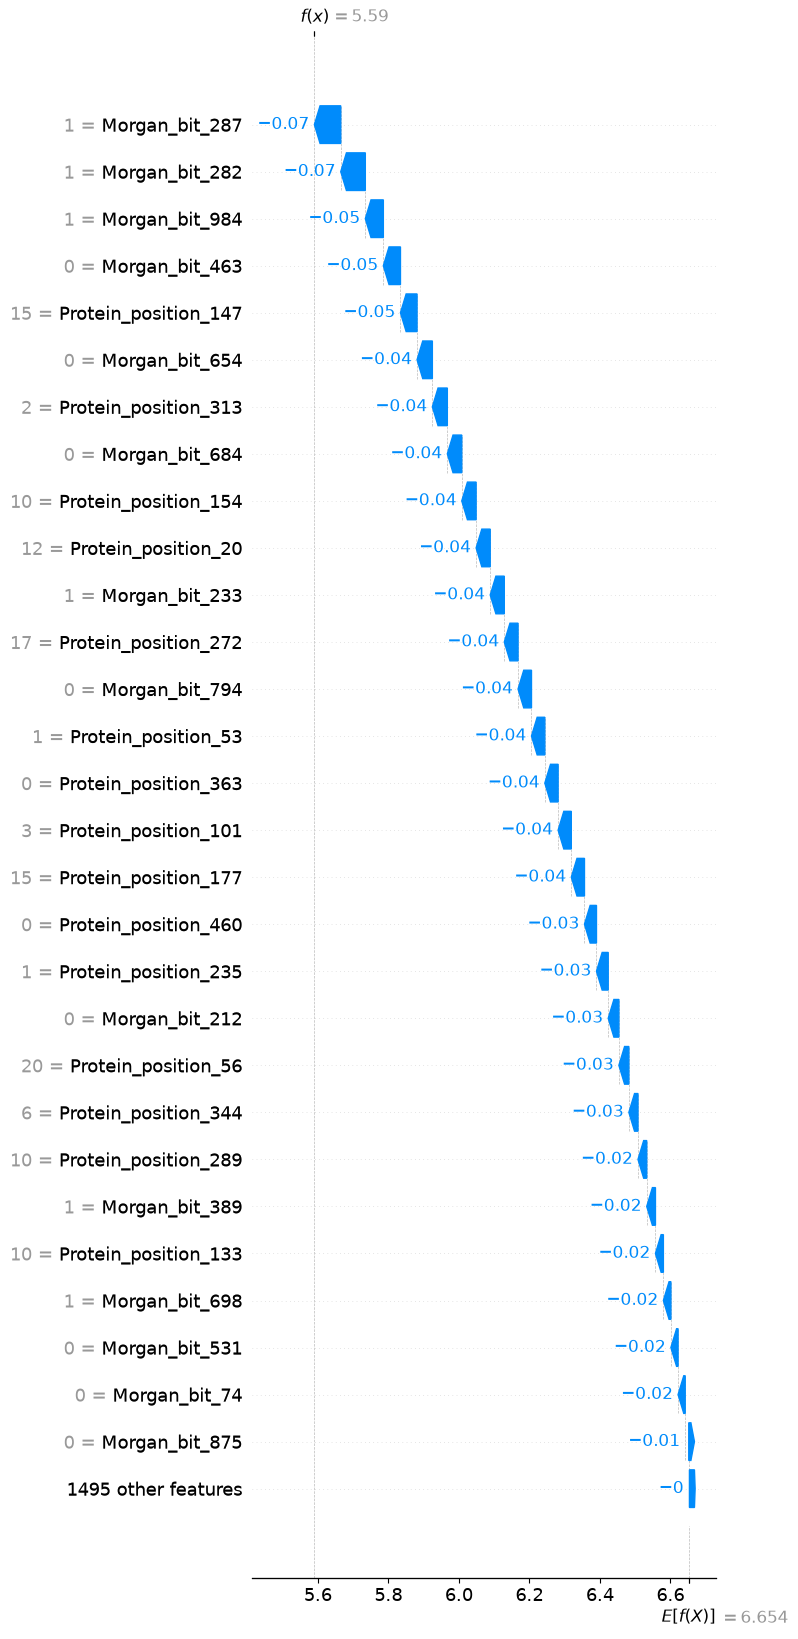

Expected value: 6.653768634796143
Model prediction: 5.589942
SHAP approximation: 5.58994197845459


In [ ]:

# Save global SHAP table

global_importance_df.to_csv(
    os.path.join(
        "outputs/",
        "global_shap_feature_importance.csv"
    ),
    index=False
)

print("\nTop 30 global SHAP features")

print(
    global_importance_df.head(30).to_string(
        index=False
    )
)


# GLOBAL PLOT 1
# SHAP combined summary bar plot

shap.summary_plot(
    shap_values,
    test_combined,
    feature_names=combined_feature_names,
    plot_type="bar",
    max_display=30,
    plot_size=(10, 8),
    show=False
)

plt.title(
    "Global SHAP Feature Importance"
)

plt.xlabel(
    "Mean |SHAP value|"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        "artifacts/shap/",
        "global_shap_combined_summary.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()





# Combined SHAP importance plot
shap.summary_plot(
    shap_values,
    test_combined,
    feature_names=combined_feature_names,
    plot_type="bar",
    max_display=30,
    plot_size=(10, 8),
    show=False
)

plt.title("SHAP Importance: Ligand and Protein")
plt.tight_layout()

plt.savefig(
    "artifacts/shap/shap_combined_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# Ligand SHAP plot
shap.summary_plot(
    ligand_shap_values,
    test_ligand,
    feature_names=ligand_feature_names,
    plot_type="bar",
    max_display=20,
    plot_size=(10, 7),
    show=False
)

plt.title("SHAP Importance: Morgan Fingerprints")
plt.tight_layout()

plt.savefig(
    "artifacts/shap/shap_ligand_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# Protein SHAP plot
shap.summary_plot(
    protein_shap_values,
    test_protein,
    feature_names=protein_feature_names,
    plot_type="bar",
    max_display=20,
    plot_size=(10, 7),
    show=False
)

plt.title("SHAP Importance: Protein Sequence Positions")
plt.tight_layout()

plt.savefig(
    "artifacts/shap/shap_protein_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()



# Combined waterfall plot
sample_index = 0

base_value = float(
    np.asarray(
        explainer.expected_value
    ).reshape(-1)[0]
)

explanation = shap.Explanation(
    values=shap_values[sample_index],
    base_values=base_value,
    data=test_combined[sample_index],
    feature_names=combined_feature_names
)

shap.plots.waterfall(
    explanation,
    max_display=30,
    show=False
)

plt.tight_layout()

plt.savefig(
    "artifacts/shap/shap_combined_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()



# Verify SHAP additivity
shap_approximation = (
    base_value
    + shap_values[sample_index].sum()
)

print("Expected value:", base_value)
print(
    "Model prediction:",
    wrapper_prediction[sample_index]
)
print(
    "SHAP approximation:",
    shap_approximation
)

In [39]:
import torch
import os


MODEL_PATH = "artifacts/models/dti_model_checkpoint.pt"

os.makedirs(
    os.path.dirname(MODEL_PATH),
    exist_ok=True
)


checkpoint = {
    # Model
    "model_state_dict": model.state_dict(),

    # Optimizer
    "optimizer_state_dict": optimizer.state_dict(),

    # Training information
    "epoch": epoch,
    "best_val_loss": best_val_loss,

    # Model configuration
    "model_config": {
        "fingerprint_size": 1024,
        "protein_vocab_size": 22,
        "protein_embedding_dim": 128,
        "padding_idx": 0,
        "dropout_rate": 0.3,
    },

    # Training configuration
    "training_config": {
        "learning_rate": 3e-4,
        "weight_decay": 1e-4,
        "batch_size": 16,
        "loss": "HuberLoss",
        "huber_delta": 1.0,
        "random_state": 42,
    }
}


torch.save(
    checkpoint,
    MODEL_PATH
)

print(f"Model saved to: {MODEL_PATH}")

Model saved to: artifacts/models/dti_model_checkpoint.pt


#final prediction/inference

In [40]:
torch.save(
    model.state_dict(),
    "artifacts/models/dti_model_best.pt"
)